# Visualizing Maps with Large Numbers of Robots

3/14/2026

In [13]:
%load_ext autoreload
%autoreload 2

import sys

from pathlib import Path

path = Path("..").resolve().as_posix()
if str(path) not in sys.path:
    sys.path.insert(0, str(path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


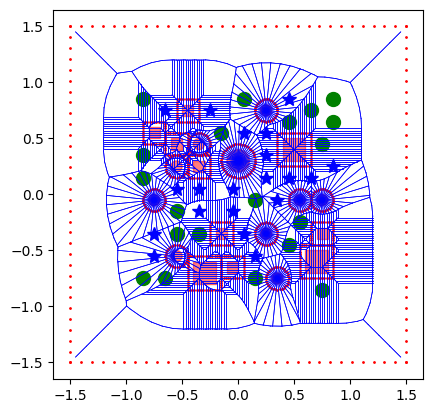

In [30]:
import ael.visualize
import pickle
import matplotlib.pyplot as plt
import ael.maps
import ael.visgraphprior

with open("../instances_data/larger/dense_maps.pkl", "rb") as f:
    data = pickle.load(f)

instance = data[0]
problem = ael.maps.load_instance_from_pickled_format(data[0])

ael.visualize.visualize(problem, plt.gca())

poly = ael.visgraphprior._create_voronoi_polygon(problem)
plt.scatter(poly[:, 0], poly[:, 1], color="red", s=1)
# for polygon in poly:
#     plt.plot(polygon[:, 0], polygon[:, 1], color="red", linewidth=0.5)

# compute voronoi
roadmap = ael.visgraphprior.make_roadmap(problem)
for node in roadmap.nodes:
    pos = roadmap.nodes[node]["pos"]
    for neighbor in roadmap.neighbors(node):
        neighbor_pos = roadmap.nodes[neighbor]["pos"]
        plt.plot(
            [pos[0], neighbor_pos[0]],
            [pos[1], neighbor_pos[1]],
            color="blue",
            linewidth=0.5,
        )

plt.show()
